# 02 Muzzle-only Classification

这个 notebook 使用 `mouse_dataset/muzzle_crops` 里面已经裁剪好的 muzzle 图片来训练分类模型。  
核心逻辑和 full-image classification 相同，区别是：

- full image classification 读取 `mouse_dataset/images`
- muzzle-only classification 读取 `mouse_dataset/muzzle_crops`
- 只保留已经成功 crop 的图片

In [1]:
from pathlib import Path
import random

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

In [9]:
# =========================
# Paths
# =========================
PROJECT_DIR = Path.cwd()

BASE_DIR = PROJECT_DIR / "mouse_dataset"

# Important: for muzzle-only classification, use cropped images here
# IMG_DIR = BASE_DIR / "muzzle_crops"
IMG_DIR = BASE_DIR / "muzzle_crops_v3"

MGS_CSV = BASE_DIR / "MouseGrimaceFaces_mgs.csv"
MAIN_CSV = BASE_DIR / "MouseGrimaceFaces_main.csv"

print("Current directory:", PROJECT_DIR)
print("Dataset path:", BASE_DIR)
print("MGS exists:", MGS_CSV.exists())
print("MAIN exists:", MAIN_CSV.exists())
print("Muzzle crop folder exists:", IMG_DIR.exists())
print("Number of crop images:", len(list(IMG_DIR.glob("*.jpg"))) + len(list(IMG_DIR.glob("*.png"))))

Current directory: /Users/baturu/Documents/Project_CV
Dataset path: /Users/baturu/Documents/Project_CV/mouse_dataset
MGS exists: True
MAIN exists: True
Muzzle crop folder exists: True
Number of crop images: 1791


In [10]:
# =========================
# Label construction
# =========================

def build_labels():
    df = pd.read_csv(MGS_CSV)
    main_df = pd.read_csv(MAIN_CSV)

    # Merge mouse identity information.
    # main_df has columns like: index, id, subset
    df = df.merge(
        main_df[["index", "id"]],
        on="index",
        how="left"
    )

    meta_cols = ["index", "subset", "id"]
    score_cols = [c for c in df.columns if c not in meta_cols]

    scores = df[score_cols].replace("-", np.nan)
    scores = scores.apply(pd.to_numeric, errors="coerce")

    # In this dataset, 9 means "cannot be judged".
    scores = scores.replace(9, np.nan)

    # Average all available MGS scores.
    df["mgs_mean"] = scores.mean(axis=1)

    # Remove images without valid MGS scores.
    df = df.dropna(subset=["mgs_mean"])

    # Binary label:
    # 0 = well-being / not impaired
    # 1 = impaired / pain-like expression
    df["label"] = (df["mgs_mean"] >= 1.0).astype(int)

    # For muzzle-only classification, image path points to crop folder.
    df["path"] = df["index"].apply(lambda x: IMG_DIR / str(x))

    before = len(df)

    # Keep only images that were successfully cropped.
    df = df[df["path"].apply(lambda p: p.exists())].copy()

    after = len(df)
    print(f"Rows before crop filtering: {before}")
    print(f"Rows after crop filtering:  {after}")
    print(f"Removed because crop image missing: {before - after}")

    return df[["index", "subset", "id", "path", "mgs_mean", "label"]].reset_index(drop=True)

In [11]:
# Build labels and inspect distribution

df = build_labels()

print("Total usable muzzle-crop images:", len(df))
print("Label distribution:")
print(df["label"].value_counts())

print("Subset distribution:")
print(df["subset"].value_counts())

df.head()

Rows before crop filtering: 3406
Rows after crop filtering:  1791
Removed because crop image missing: 1615
Total usable muzzle-crop images: 1791
Label distribution:
label
0    1430
1     361
Name: count, dtype: int64
Subset distribution:
subset
KH    721
MR    584
LW    304
AW     97
JW     85
Name: count, dtype: int64


,index,subset,id,path,mgs_mean,label
0,000008.jpg,KH,94,/Users/baturu/Documents/Project_CV/mouse_datas...,0.200000,0
1,000015.jpg,JW,202,/Users/baturu/Documents/Project_CV/mouse_datas...,0.533333,0
2,000031.jpg,KH,110,/Users/baturu/Documents/Project_CV/mouse_datas...,0.400000,0
3,000035.jpg,KH,119,/Users/baturu/Documents/Project_CV/mouse_datas...,1.071429,1
4,000039.jpg,MR,2,/Users/baturu/Documents/Project_CV/mouse_datas...,1.300000,1


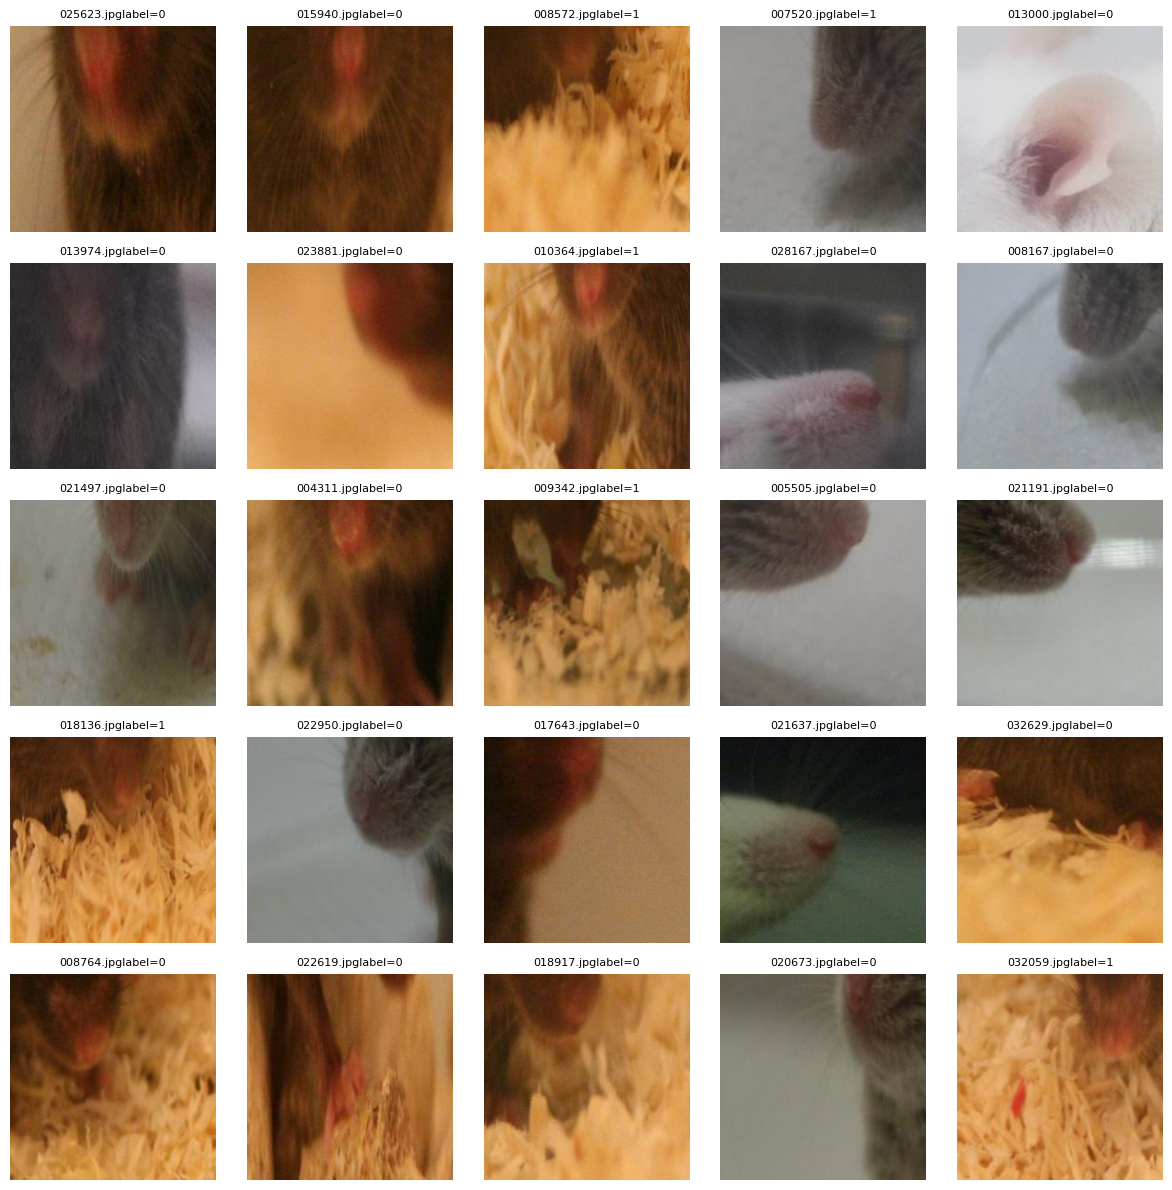

In [12]:
# Optional: visualize random muzzle crops before training

sample_df = df.sample(n=min(25, len(df)), random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f'{row["index"]}label={row["label"]}', fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
# =========================
# Dataset
# =========================

class MouseDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["label"], dtype=torch.long)

        return img, label

In [14]:
# =========================
# Train / validation split
# =========================

# We split by mouse identity, not by individual image.
# This avoids putting images from the same mouse in both train and validation.

def make_group_split(df):
    groups = df["subset"].astype(str) + "_" + df["id"].astype(str)

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, val_idx = next(
        splitter.split(df, y=df["label"], groups=groups)
    )

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    return train_df, val_df

train_df, val_df = make_group_split(df)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

print("Train label distribution:")
print(train_df["label"].value_counts())

print("Validation label distribution:")
print(val_df["label"].value_counts())

Train size: 1471
Validation size: 320
Train label distribution:
label
0    1181
1     290
Name: count, dtype: int64
Validation label distribution:
label
0    249
1     71
Name: count, dtype: int64


In [15]:
# =========================
# Transforms and dataloaders
# =========================

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_ds = MouseDataset(train_df, transform=train_tfms)
val_ds = MouseDataset(val_df, transform=val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [16]:
# =========================
# Device
# =========================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [17]:
# =========================
# Model
# =========================

model = models.convnext_tiny(
    weights=models.ConvNeXt_Tiny_Weights.DEFAULT
)

# Replace ImageNet classifier with binary classifier.
model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    2
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [18]:
# =========================
# Training and evaluation functions
# =========================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for imgs, labels in tqdm(loader, desc="Training"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Validation"):
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [19]:
# =========================
# Train
# =========================

EPOCHS = 30

history = []

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    y_true, y_pred = evaluate(model, val_loader, device)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=["well-being", "impaired"],
        zero_division=0
    )

    print("Train loss:", train_loss)
    print("Confusion matrix:")
    print(cm)
    print("Classification report:")
    print(report)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
    })

Epoch 1/30


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.83it/s]


Train loss: 0.4352962173845457
Confusion matrix:
[[244   5]
 [ 59  12]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.81      0.98      0.88       249
    impaired       0.71      0.17      0.27        71

    accuracy                           0.80       320
   macro avg       0.76      0.57      0.58       320
weighted avg       0.78      0.80      0.75       320

Epoch 2/30


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.79it/s]


Train loss: 0.37278109788894653
Confusion matrix:
[[219  30]
 [ 26  45]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.89      0.88      0.89       249
    impaired       0.60      0.63      0.62        71

    accuracy                           0.82       320
   macro avg       0.75      0.76      0.75       320
weighted avg       0.83      0.82      0.83       320

Epoch 3/30


...

Train loss: 0.03269237246390928
Confusion matrix:
[[226  23]
 [ 36  35]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.86      0.91      0.88       249
    impaired       0.60      0.49      0.54        71

    accuracy                           0.82       320
   macro avg       0.73      0.70      0.71       320
weighted avg       0.81      0.82      0.81       320

Epoch 29/30


Validation: 100%|██████████| 10/10 [00:06<00:00,  1.59it/s]


Train loss: 0.0161132659084852
Confusion matrix:
[[234  15]
 [ 46  25]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.84      0.94      0.88       249
    impaired       0.62      0.35      0.45        71

    accuracy                           0.81       320
   macro avg       0.73      0.65      0.67       320
weighted avg       0.79      0.81      0.79       320

Epoch 30/30


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.79it/s]

Train loss: 0.011452712242949612
Confusion matrix:
[[239  10]
 [ 49  22]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.83      0.96      0.89       249
    impaired       0.69      0.31      0.43        71

    accuracy                           0.82       320
   macro avg       0.76      0.63      0.66       320
weighted avg       0.80      0.82      0.79       320



In [20]:
# =========================
# Save model
# =========================

SAVE_PATH = PROJECT_DIR / "mouse_wellbeing_muzzle_convnext_tiny.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_mapping": {
            0: "well-being",
            1: "impaired"
        },
        "image_dir": str(IMG_DIR),
        "note": "Muzzle-only classifier trained on DLC-cropped images."
    },
    SAVE_PATH
)

print("Saved model to:", SAVE_PATH)

Saved model to: /Users/baturu/Documents/Project_CV/mouse_wellbeing_muzzle_convnext_tiny.pt


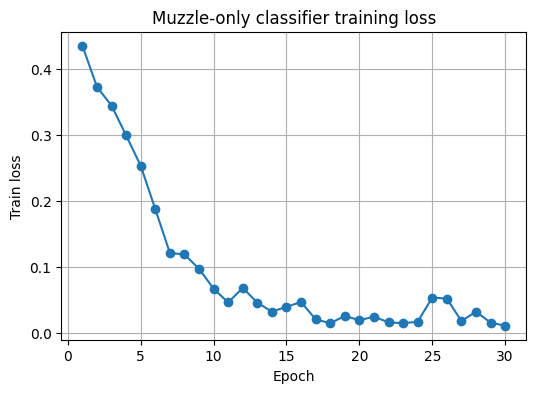

In [21]:
# Optional: plot training loss

history_df = pd.DataFrame(history)

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Muzzle-only classifier training loss")
plt.grid(True)
plt.show()

# check if the model remember the train dataset

Epoch 1/30


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.76it/s]


Train loss: 0.0247
Train accuracy: 0.9973
Validation accuracy: 0.7969
Train macro F1: 0.9957
Validation macro F1: 0.7073
Train impaired F1: 0.9932
Validation impaired F1: 0.5455
Train impaired recall: 1.0000
Validation impaired recall: 0.5493
Macro F1 gap: 0.2884

Validation confusion matrix:
[[216  33]
 [ 32  39]]

Validation classification report:
              precision    recall  f1-score   support

  well-being       0.87      0.87      0.87       249
    impaired       0.54      0.55      0.55        71

    accuracy                           0.80       320
   macro avg       0.71      0.71      0.71       320
weighted avg       0.80      0.80      0.80       320

Saved best model at epoch 1
Epoch 2/30


Validation: 100%|██████████| 10/10 [00:08<00:00,  1.20it/s]


Train loss: 0.0108
Train accuracy: 0.9993
Validation accuracy: 0.8031
Train macro F1: 0.9989
Validation macro F1: 0.6748
Train impaired F1: 0.9983
Validation impaired F1: 0.4706
Train impaired recall: 1.0000
Validation impaired recall: 0.3944
Macro F1 gap: 0.3241

Validation confusion matrix:
[[229  20]
 [ 43  28]]

Validation classification report:
              precision    recall  f1-score   support

  well-being       0.84      0.92      0.88       249
    impaired       0.58      0.39      0.47        71

    accuracy                           0.80       320
   macro avg       0.71      0.66      0.67       320
weighted avg       0.78      0.80      0.79       320

Epoch 3/30


...

Validation: 100%|██████████| 10/10 [00:06<00:00,  1.62it/s]


Train loss: 0.0044
Train accuracy: 0.9993
Validation accuracy: 0.8219
Train macro F1: 0.9989
Validation macro F1: 0.6802
Train impaired F1: 0.9983
Validation impaired F1: 0.4673
Train impaired recall: 0.9966
Validation impaired recall: 0.3521
Macro F1 gap: 0.3188

Validation confusion matrix:
[[238  11]
 [ 46  25]]

Validation classification report:
              precision    recall  f1-score   support

  well-being       0.84      0.96      0.89       249
    impaired       0.69      0.35      0.47        71

    accuracy                           0.82       320
   macro avg       0.77      0.65      0.68       320
weighted avg       0.81      0.82      0.80       320

Epoch 30/30


Validation: 100%|██████████| 10/10 [00:06<00:00,  1.61it/s]

Train loss: 0.0155
Train accuracy: 0.9952
Validation accuracy: 0.8094
Train macro F1: 0.9924
Validation macro F1: 0.6676
Train impaired F1: 0.9878
Validation impaired F1: 0.4505
Train impaired recall: 0.9759
Validation impaired recall: 0.3521
Macro F1 gap: 0.3248

Validation confusion matrix:
[[234  15]
 [ 46  25]]

Validation classification report:
              precision    recall  f1-score   support

  well-being       0.84      0.94      0.88       249
    impaired       0.62      0.35      0.45        71

    accuracy                           0.81       320
   macro avg       0.73      0.65      0.67       320
weighted avg       0.79      0.81      0.79       320

Best epoch: 25
Best validation macro F1: 0.7693
Best model saved to: best_muzzle_model.pt


,epoch,train_loss,train_acc,val_acc,train_macro_f1,val_macro_f1,train_impaired_f1,val_impaired_f1,train_impaired_recall,val_impaired_recall,generalization_gap_macro_f1,generalization_gap_impaired_f1
0,1,0.024654,0.997281,0.796875,0.995727,0.707335,0.993151,0.545455,1.000000,0.549296,0.288392,0.447696
1,2,0.010832,0.999320,0.803125,0.998928,0.674833,0.998279,0.470588,1.000000,0.394366,0.324094,0.527691
2,3,0.019263,0.999320,0.787500,0.998928,0.692290,0.998279,0.521127,1.000000,0.521127,0.306637,0.477152
3,4,0.008624,0.995921,0.803125,0.993507,0.623593,0.989547,0.363636,0.979310,0.253521,0.369914,0.625911
4,5,0.004621,1.000000,0.812500,1.000000,0.644444,1.000000,0.400000,1.000000,0.281690,0.355556,0.600000
5,6,0.006052,0.998640,0.815625,0.997852,0.682961,0.996552,0.477876,0.996552,0.380282,0.314892,0.518676
6,7,0.011402,0.998640,0.793750,0.997858,0.661538,0.996564,0.450000,1.000000,0.380282,0.336320,0.546564
7,8,0.016157,0.999320,0.806250,0.998925,0.649495,0.998273,0.415094,0.996552,0.309859,0.349430,0.583179
8,9,0.005944,1.000000,0.825000,1.000000,0.723303,1.000000,0.555556,1.000000,0.492958,0.276697,0.444444
9,10,0.003807,1.000000,0.809375,1.000000,0.693038,1.000000,0.504065,1.000000,0.436620,0.306962,0.495935


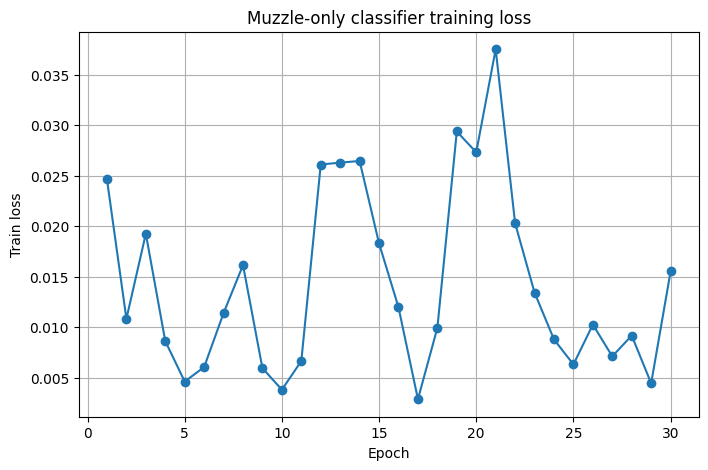

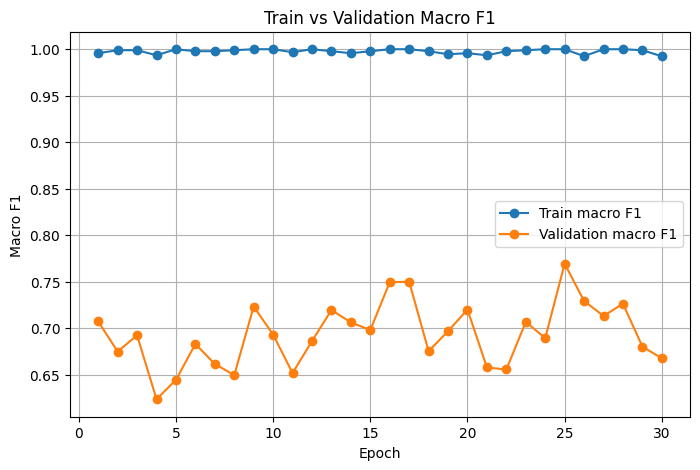

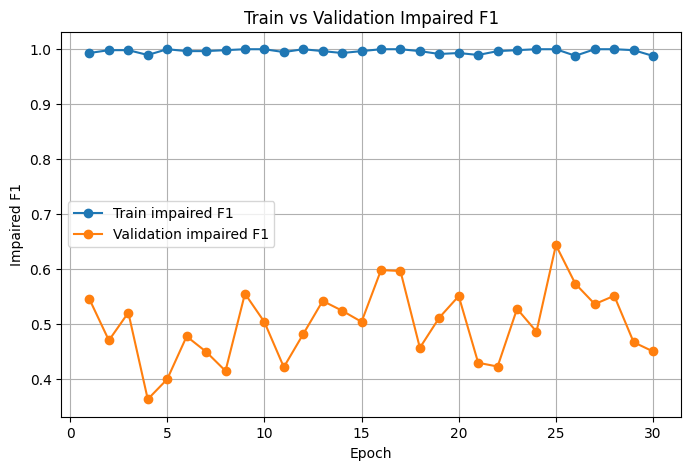

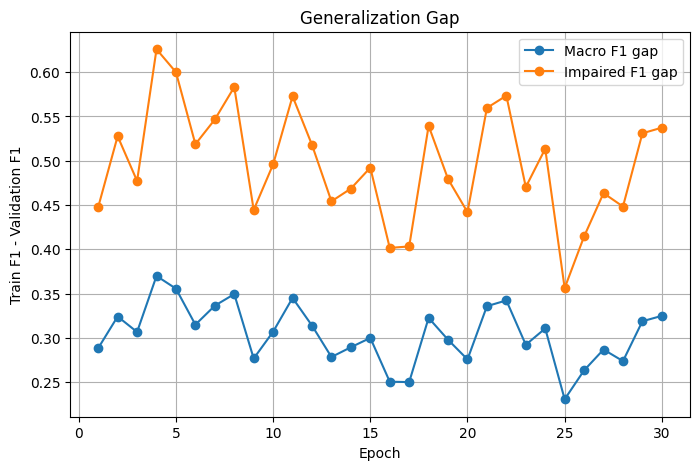

Memorization / overfitting diagnosis:
Strong sign of memorization / overfitting.
Final train macro F1: 0.9924
Final validation macro F1: 0.6676
Final macro F1 gap: 0.3248


In [22]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# Train one epoch
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for imgs, labels in tqdm(loader, desc="Training"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    return avg_loss


# =========================
# Evaluate model
# =========================
def evaluate(model, loader, device, desc="Evaluation"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=desc):
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds


# =========================
# Training loop with memorization check
# =========================
EPOCHS = 30

history = []

best_val_macro_f1 = 0.0
best_epoch = 0
best_model_path = "best_muzzle_model.pt"

for epoch in range(EPOCHS):
    print("=" * 60)
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    # ---- Train ----
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # ---- Evaluate on training set ----
    train_true, train_pred = evaluate(
        model=model,
        loader=train_loader,
        device=device,
        desc="Train evaluation"
    )

    # ---- Evaluate on validation set ----
    val_true, val_pred = evaluate(
        model=model,
        loader=val_loader,
        device=device,
        desc="Validation"
    )

    # ---- Metrics ----
    train_acc = accuracy_score(train_true, train_pred)
    val_acc = accuracy_score(val_true, val_pred)

    train_macro_f1 = f1_score(
        train_true,
        train_pred,
        average="macro",
        zero_division=0
    )

    val_macro_f1 = f1_score(
        val_true,
        val_pred,
        average="macro",
        zero_division=0
    )

    train_impaired_f1 = f1_score(
        train_true,
        train_pred,
        pos_label=1,
        zero_division=0
    )

    val_impaired_f1 = f1_score(
        val_true,
        val_pred,
        pos_label=1,
        zero_division=0
    )

    train_impaired_recall = classification_report(
        train_true,
        train_pred,
        output_dict=True,
        zero_division=0
    )["1"]["recall"]

    val_impaired_recall = classification_report(
        val_true,
        val_pred,
        output_dict=True,
        zero_division=0
    )["1"]["recall"]

    # ---- Save history ----
    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "train_macro_f1": train_macro_f1,
        "val_macro_f1": val_macro_f1,
        "train_impaired_f1": train_impaired_f1,
        "val_impaired_f1": val_impaired_f1,
        "train_impaired_recall": train_impaired_recall,
        "val_impaired_recall": val_impaired_recall,
        "generalization_gap_macro_f1": train_macro_f1 - val_macro_f1,
        "generalization_gap_impaired_f1": train_impaired_f1 - val_impaired_f1,
    })

    # ---- Print metrics ----
    print(f"Train loss: {train_loss:.4f}")
    print(f"Train accuracy: {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Train macro F1: {train_macro_f1:.4f}")
    print(f"Validation macro F1: {val_macro_f1:.4f}")
    print(f"Train impaired F1: {train_impaired_f1:.4f}")
    print(f"Validation impaired F1: {val_impaired_f1:.4f}")
    print(f"Train impaired recall: {train_impaired_recall:.4f}")
    print(f"Validation impaired recall: {val_impaired_recall:.4f}")
    print(f"Macro F1 gap: {train_macro_f1 - val_macro_f1:.4f}")

    print("\nValidation confusion matrix:")
    print(confusion_matrix(val_true, val_pred))

    print("\nValidation classification report:")
    print(classification_report(
        val_true,
        val_pred,
        target_names=["well-being", "impaired"],
        zero_division=0
    ))

    # ---- Save best model according to validation macro F1 ----
    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_epoch = epoch + 1
        torch.save(model.state_dict(), best_model_path)
        print(f"Saved best model at epoch {best_epoch}")

print("=" * 60)
print(f"Best epoch: {best_epoch}")
print(f"Best validation macro F1: {best_val_macro_f1:.4f}")
print(f"Best model saved to: {best_model_path}")


# =========================
# Convert history to dataframe
# =========================
history_df = pd.DataFrame(history)
display(history_df)


# =========================
# Plot 1: Train loss
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Muzzle-only classifier training loss")
plt.grid(True)
plt.show()


# =========================
# Plot 2: Train vs Validation Macro F1
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], marker="o", label="Train macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], marker="o", label="Validation macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Train vs Validation Macro F1")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Plot 3: Train vs Validation Impaired F1
# =========================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_impaired_f1"], marker="o", label="Train impaired F1")
plt.plot(history_df["epoch"], history_df["val_impaired_f1"], marker="o", label="Validation impaired F1")
plt.xlabel("Epoch")
plt.ylabel("Impaired F1")
plt.title("Train vs Validation Impaired F1")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Plot 4: Generalization gap
# =========================
plt.figure(figsize=(8, 5))
plt.plot(
    history_df["epoch"],
    history_df["generalization_gap_macro_f1"],
    marker="o",
    label="Macro F1 gap"
)
plt.plot(
    history_df["epoch"],
    history_df["generalization_gap_impaired_f1"],
    marker="o",
    label="Impaired F1 gap"
)
plt.xlabel("Epoch")
plt.ylabel("Train F1 - Validation F1")
plt.title("Generalization Gap")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# Simple diagnosis
# =========================
last = history_df.iloc[-1]

print("=" * 60)
print("Memorization / overfitting diagnosis:")

if last["generalization_gap_macro_f1"] > 0.15:
    print("Strong sign of memorization / overfitting.")
elif last["generalization_gap_macro_f1"] > 0.08:
    print("Moderate sign of overfitting.")
else:
    print("No strong sign of memorization based on macro F1 gap.")

print(f"Final train macro F1: {last['train_macro_f1']:.4f}")
print(f"Final validation macro F1: {last['val_macro_f1']:.4f}")
print(f"Final macro F1 gap: {last['generalization_gap_macro_f1']:.4f}")